In [1]:
# ==============================
# Titanic Dataset Preprocessing
# Google Colab
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# ---------------------------------
# Handle Missing Values
# ---------------------------------

# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill Fare with median (if needed)
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Drop Cabin (many missing values)
df.drop("Cabin", axis=1, inplace=True)

# ---------------------------------
# Remove Duplicates
# ---------------------------------
df.drop_duplicates(inplace=True)

# ---------------------------------
# Encode Categorical Variables
# ---------------------------------
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

# ---------------------------------
# Drop Unnecessary Columns
# ---------------------------------
df.drop(["Name", "Ticket", "PassengerId"], axis=1, inplace=True)

# ---------------------------------
# Feature Scaling
# ---------------------------------
scaler = StandardScaler()

df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

# ---------------------------------
# Final Dataset
# ---------------------------------
print("\nPreprocessed Dataset:")
print(df.head())

print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

print("\nDataset Shape:", df.shape)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

Original Dataset
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Missing Values Before Preprocessing
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class        

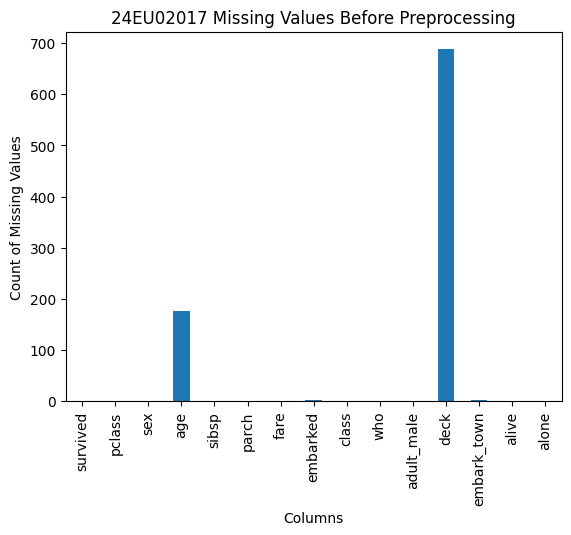


Missing Values After Preprocessing
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64

Preprocessed Dataset
   survived  pclass  sex   age  sibsp  parch     fare  embarked  adult_male  \
0         0       3    1  22.0      1      0   7.2500         2           1   
1         1       1    0  38.0      1      0  71.2833         0           0   
2         1       3    0  26.0      0      0   7.9250         2           0   
3         1       1    0  35.0      1      0  53.1000         2           0   
4         0       3    1  35.0      0      0   8.0500         2           1   

   alone  
0      0  
1      0  
2      1  
3      0  
4      1  


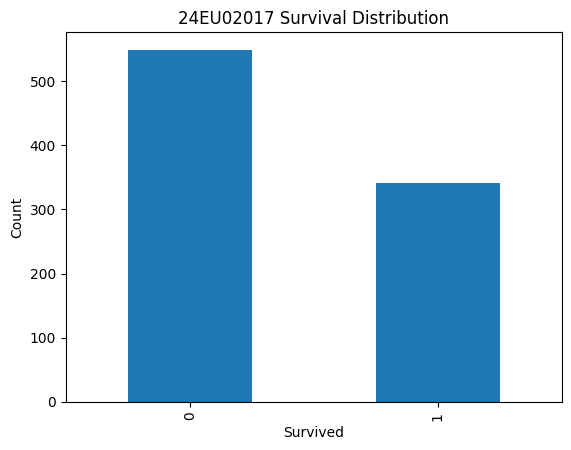

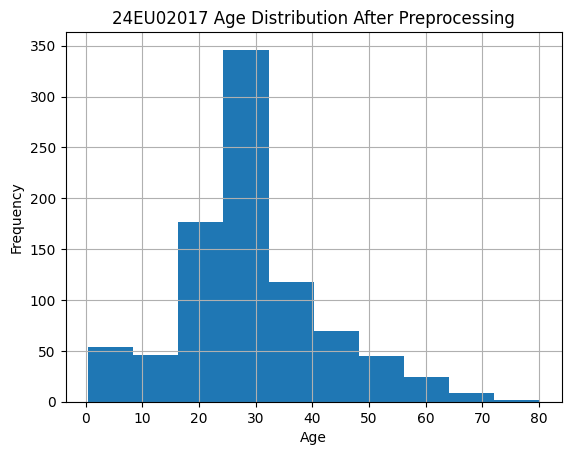

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Display first 5 rows
print("Original Dataset")
print(df.head())

# Check missing values
print("\nMissing Values Before Preprocessing")
print(df.isnull().sum())

# Visualization of missing values
df.isnull().sum().plot(kind='bar')
plt.title("24EU02017 Missing Values Before Preprocessing")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.show()

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop columns with many missing values
df.drop(['deck', 'embark_town', 'alive', 'class', 'who'], axis=1, inplace=True)

# Encode categorical columns
le = LabelEncoder()

categorical_columns = ['sex', 'adult_male', 'alone', 'embarked']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Check missing values after preprocessing
print("\nMissing Values After Preprocessing")
print(df.isnull().sum())

# Display preprocessed dataset
print("\nPreprocessed Dataset")
print(df.head())

# Visualization after preprocessing
df['survived'].value_counts().plot(kind='bar')
plt.title("24EU02017 Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

df['age'].hist()
plt.title("24EU02017 Age Distribution After Preprocessing")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()